Improved linear trend benchmark; It uses only information available up to the forecast origin, anchors the path at the current outage fraction, and projects a straight line forward. For the recovery metrics, use remaining time to 50% and 10% of the current outage level. That keeps the model operationally sensible; peak-based metrics would use future information.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients"

event_master = pd.read_parquet(f"{path}\\florida_event_master.parquet")
model_df = pd.read_parquet(f"{path}\\florida_model_df.parquet")

# Keep a quality filter, as before
df = model_df.loc[model_df["customersTracked"] >= 0.3].copy()

# Create a stable series key if needed
if "series_id" not in df.columns:
    df["series_id"] = df["event_id"].astype(str) + "__" + df["CountyFIPS"].astype(str)

df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values(["series_id", "datetime"]).reset_index(drop=True)

In [28]:
# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------
def get_series(df: pd.DataFrame, series_id: str) -> pd.DataFrame:
    """Return one event-county series sorted by time."""
    out = df.loc[df["series_id"] == series_id].copy()
    return out.sort_values("datetime").reset_index(drop=True)


def fit_local_linear_trend(series_df: pd.DataFrame,
                           origin_datetime: pd.Timestamp,
                           lookback_hours: int = 24 ): # doubling this to try
    """
    Fit a simple linear trend to outageFraction using only observations
    up to the origin time.

    The forecast is anchored at the current observed outageFraction and
    then extended forward with the estimated slope.

    If the fitted slope is positive, we clip it to 0.0 so the baseline
    becomes flat rather than inventing an increasing "recovery" path.
    """
    origin_datetime = pd.Timestamp(origin_datetime)

    origin_row = series_df.loc[series_df["datetime"] == origin_datetime]
    if origin_row.empty:
        return None

    y0 = float(origin_row["outageFraction"].iloc[0])

    past = series_df.loc[
        (series_df["datetime"] <= origin_datetime) &
        (series_df["datetime"] >= origin_datetime - pd.Timedelta(hours=lookback_hours))
    ].copy().sort_values("datetime")

    if len(past) < 3:
        return None

    # Time relative to the forecast origin, in hours
    x = ((past["datetime"] - origin_datetime).dt.total_seconds() / 3600.0).to_numpy()
    y = past["outageFraction"].to_numpy(dtype=float)

    # Linear fit: y = a + b * x
    slope, intercept = np.polyfit(x, y, 1)

    # Operationally conservative baseline: no increase after origin
    slope = min(float(slope), 0.0)

    return {
        "y0": y0,
        "slope": slope,
        "intercept": float(intercept),
        "origin_datetime": origin_datetime,
    }


def forecast_linear_path(y0: float, slope: float, horizon_hours: int = 72):
    """Generate a linear forecast path from the current state."""
    h = np.arange(0, horizon_hours + 1, dtype=float)
    yhat = np.clip(y0 + slope * h, 0.0, 1.0)
    return h, yhat


def remaining_time_to_threshold(y0: float, slope: float, threshold: float):
    """
    Time from the origin until the linear forecast reaches a given threshold.
    Returns NaN if the path never reaches the threshold.
    """
    if y0 <= threshold:
        return 0.0
    if slope >= 0:
        return np.nan
    return max((threshold - y0) / slope, 0.0)


def observed_remaining_time(series_df: pd.DataFrame,
                            origin_datetime: pd.Timestamp,
                            threshold: float):
    """
    Time from origin until the actual series first drops to or below threshold.
    """
    origin_datetime = pd.Timestamp(origin_datetime)
    post = series_df.loc[series_df["datetime"] >= origin_datetime].copy().sort_values("datetime")
    hit = post.loc[post["outageFraction"] <= threshold]
    if hit.empty:
        return np.nan
    return (hit["datetime"].iloc[0] - origin_datetime).total_seconds() / 3600.0


def get_actual_at_horizon(series_df: pd.DataFrame,
                          origin_datetime: pd.Timestamp,
                          horizon_hours: int):
    """Actual outageFraction at origin + horizon_hours, or NaN if missing."""
    target_time = pd.Timestamp(origin_datetime) + pd.Timedelta(hours=horizon_hours)
    row = series_df.loc[series_df["datetime"] == target_time]
    if row.empty:
        return np.nan
    return float(row["outageFraction"].iloc[0])

In [29]:
# ---------------------------------------------------------------------
# Build a rolling-origin evaluation table
# ---------------------------------------------------------------------
def build_linear_decay_eval(series_df: pd.DataFrame,
                            min_history_hours: int = 72,
                            lookback_hours: int = 24 ,
                            forecast_horizons=(24, 48, 72),
                            origin_step_hours: int = 12) -> pd.DataFrame:
    """
    For one series, generate rolling-origin linear-decay forecasts and
    record both trajectory errors and recovery-time errors.
    """
    series_df = series_df.sort_values("datetime").reset_index(drop=True)
    times = series_df["datetime"].drop_duplicates().sort_values().to_list()

    if len(times) == 0:
        return pd.DataFrame()

    start_time = times[0] + pd.Timedelta(hours=min_history_hours)
    origins = [t for t in times if t >= start_time]

    # Subsample origins every origin_step_hours
    origin_index = pd.Index(origins)
    if len(origin_index) == 0:
        return pd.DataFrame()

    sampled_origins = origin_index[::origin_step_hours].to_list()

    rows = []
    for origin in sampled_origins:
        fit = fit_local_linear_trend(series_df, origin, lookback_hours=lookback_hours)
        if fit is None:
            continue

        y0 = fit["y0"]
        slope = fit["slope"]

        # Thresholds relative to the current observed level
        thr50 = 0.5 * y0
        thr90 = 0.1 * y0

        pred_t50 = remaining_time_to_threshold(y0, slope, thr50)
        pred_t90 = remaining_time_to_threshold(y0, slope, thr90)

        act_t50 = observed_remaining_time(series_df, origin, thr50)
        act_t90 = observed_remaining_time(series_df, origin, thr90)

        # Trajectory forecast errors at fixed horizons
        for h in forecast_horizons:
            y_true = get_actual_at_horizon(series_df, origin, h)
            y_pred = float(np.clip(y0 + slope * h, 0.0, 1.0))

            rows.append({
                "series_id": series_df["series_id"].iloc[0],
                "event_id": series_df["event_id"].iloc[0],
                "CountyFIPS": series_df["CountyFIPS"].iloc[0],
                "storm": series_df["storm"].iloc[0],
                "origin_datetime": origin,
                "forecast_horizon_hours": h,
                "y0": y0,
                "slope": slope,
                "threshold_50": thr50,
                "threshold_90": thr90,
                "pred_t50_remaining": pred_t50,
                "pred_t90_remaining": pred_t90,
                "act_t50_remaining": act_t50,
                "act_t90_remaining": act_t90,
                "y_true": y_true,
                "y_pred": y_pred,
            })

    return pd.DataFrame(rows)


# Build one evaluation table for all Florida series
all_eval = []
for sid in df["series_id"].drop_duplicates():
    s = get_series(df, sid)
    ev = build_linear_decay_eval(
        s,
        min_history_hours=72,
        lookback_hours=24 ,
        forecast_horizons=(24, 48, 72),
        origin_step_hours=12,
    )
    if not ev.empty:
        all_eval.append(ev)

linear_eval_df = pd.concat(all_eval, ignore_index=True) if all_eval else pd.DataFrame()
linear_eval_df.head()

,series_id,event_id,CountyFIPS,storm,origin_datetime,forecast_horizon_hours,y0,slope,threshold_50,threshold_90,pred_t50_remaining,pred_t90_remaining,act_t50_remaining,act_t90_remaining,y_true,y_pred
0,12001_2017-09-11 03:00:00__12001,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-13 15:00:00,24,0.190453,-0.003906,0.095227,0.019045,24.379051,43.882291,4.0,73.0,0.156974,0.096707
1,12001_2017-09-11 03:00:00__12001,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-13 15:00:00,48,0.190453,-0.003906,0.095227,0.019045,24.379051,43.882291,4.0,73.0,0.108752,0.002961
2,12001_2017-09-11 03:00:00__12001,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-13 15:00:00,72,0.190453,-0.003906,0.095227,0.019045,24.379051,43.882291,4.0,73.0,0.064698,0.000000
3,12001_2017-09-11 03:00:00__12001,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-14 03:00:00,24,0.171168,-0.003655,0.085584,0.017117,23.412999,42.143398,43.0,61.0,0.117482,0.083438
4,12001_2017-09-11 03:00:00__12001,12001_2017-09-11 03:00:00,12001,2017242N16333,2017-09-14 03:00:00,48,0.171168,-0.003655,0.085584,0.017117,23.412999,42.143398,43.0,61.0,0.084191,0.000000


In [30]:
# ---------------------------------------------------------------------
# Horizon-level forecast error summary
# ---------------------------------------------------------------------
def rmse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[mask] - b[mask]) ** 2)))


def mae(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[mask] - b[mask])))


trajectory_summary = (
    linear_eval_df
    .groupby("forecast_horizon_hours")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "rmse": rmse(g["y_true"], g["y_pred"]),
        "mae": mae(g["y_true"], g["y_pred"]),
        "bias": float(np.nanmean(g["y_pred"] - g["y_true"])),
    }))
    .reset_index()
)

trajectory_summary

,forecast_horizon_hours,n,rmse,mae,bias
0,24,902.0,0.122308,0.079377,-0.009695
1,48,902.0,0.165927,0.116373,-0.004230
2,72,902.0,0.210120,0.147190,0.016303


In [31]:
# ---------------------------------------------------------------------
# Recovery-time summary: remaining time to 50% and 10% of current level
# ---------------------------------------------------------------------
recovery_summary = (
    linear_eval_df
    .groupby("forecast_horizon_hours")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "t50_mae": mae(g["act_t50_remaining"], g["pred_t50_remaining"]),
        "t50_rmse": rmse(g["act_t50_remaining"], g["pred_t50_remaining"]),
        "t90_mae": mae(g["act_t90_remaining"], g["pred_t90_remaining"]),
        "t90_rmse": rmse(g["act_t90_remaining"], g["pred_t90_remaining"]),
    }))
    .reset_index()
)

recovery_summary

,forecast_horizon_hours,n,t50_mae,t50_rmse,t90_mae,t90_rmse
0,24,902.0,1.369736e+15,9.893116e+15,8.221171e+14,9.130092e+15
1,48,902.0,1.369736e+15,9.893116e+15,8.221171e+14,9.130092e+15
2,72,902.0,1.369736e+15,9.893116e+15,8.221171e+14,9.130092e+15


In [32]:
# these are supposed to be in units of hours, which means systematic issue:
# Many predictions are likely NaN vs finite mismatches, or
# The linear model often predicts no recovery (NaN) while actual does recover (or vice versa), or
# Thresholds are sometimes never reached → very large implicit errors
# ---
# Check how many valid comparisons you actually have:
linear_eval_df[['act_t50_remaining','pred_t50_remaining']].notna().mean()

act_t50_remaining     0.893570
pred_t50_remaining    0.871397
dtype: float64

In [33]:
np.isfinite(linear_eval_df['pred_t50_remaining']).mean()

np.float64(0.8713968957871396)

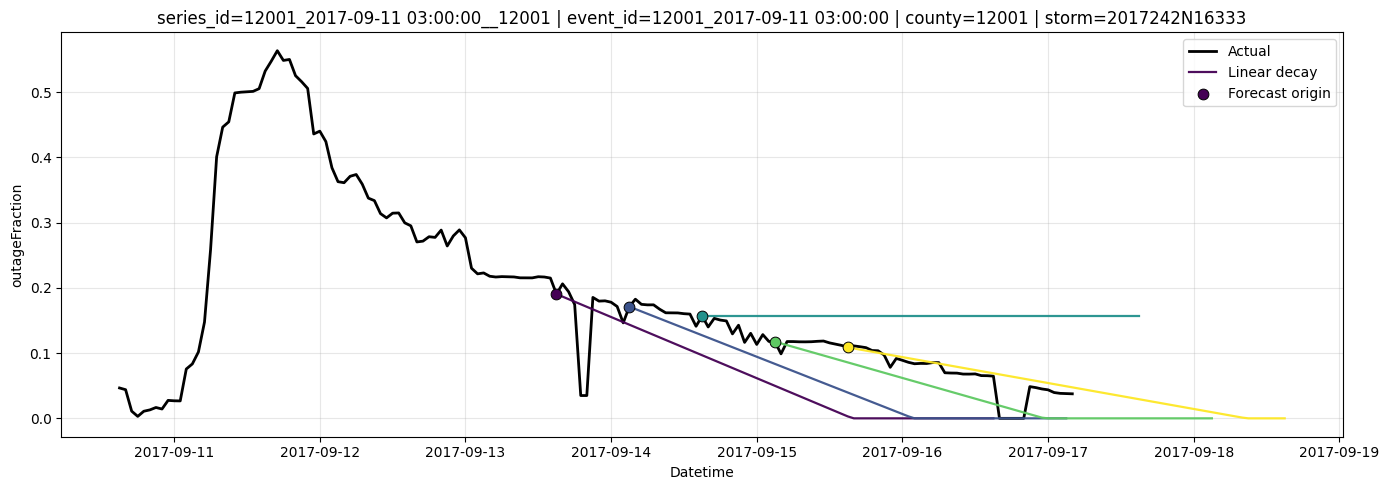

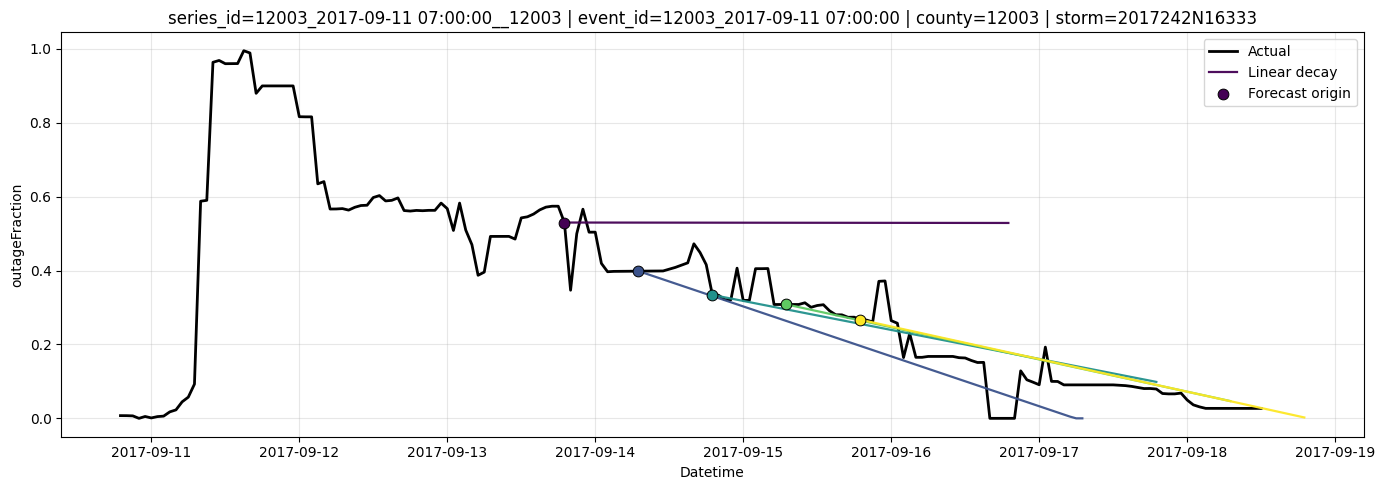

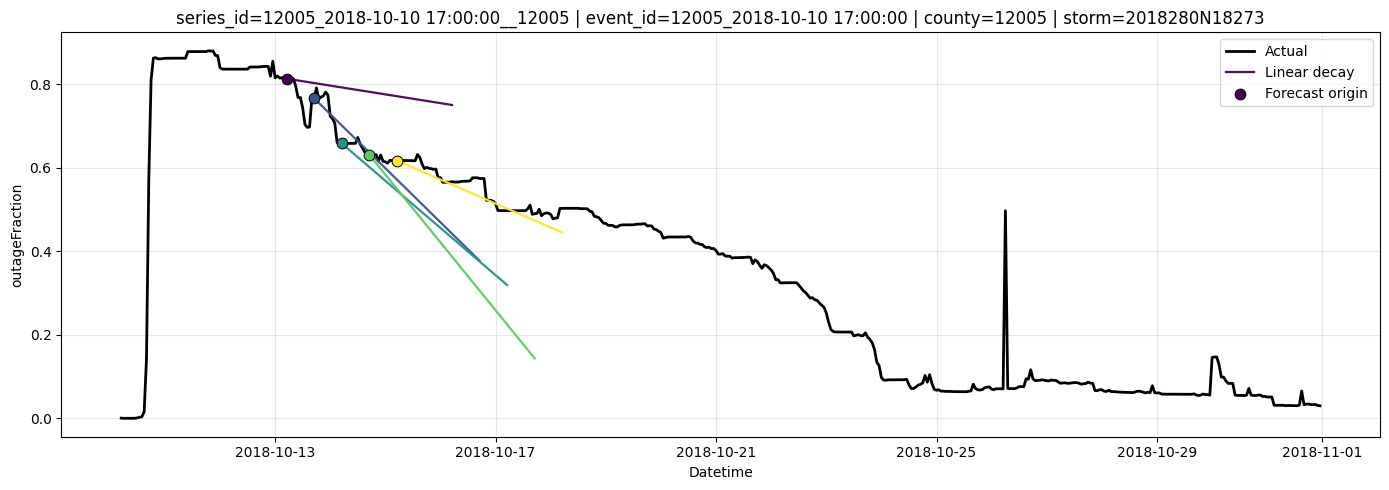

In [34]:
# ---------------------------------------------------------------------
# Visualise a few example series, TFT-style
# ---------------------------------------------------------------------
def plot_linear_decay_paths(series_id: str,
                            origin_step_hours: int = 12,
                            min_history_hours: int = 72,
                            lookback_hours: int = 24 ,
                            horizon_hours: int = 72,
                            max_origins: int = 5) -> None:
    series_df = get_series(df, series_id)
    if series_df.empty:
        return

    times = series_df["datetime"].drop_duplicates().sort_values().to_list()
    start_time = times[0] + pd.Timedelta(hours=min_history_hours)
    origins = [t for t in times if t >= start_time][::origin_step_hours][:max_origins]

    if len(origins) == 0:
        return

    event_id = series_df["event_id"].iloc[0]
    county = series_df["CountyFIPS"].iloc[0]
    storm = series_df["storm"].iloc[0]

    cmap = plt.cm.viridis
    norm = Normalize(vmin=0, vmax=max(1, len(origins) - 1))

    fig, ax = plt.subplots(figsize=(14, 5))

    # Actual outage trajectory
    ax.plot(series_df["datetime"], series_df["outageFraction"],
            color="black", linewidth=2, label="Actual")

    for j, origin in enumerate(origins):
        fit = fit_local_linear_trend(series_df, origin, lookback_hours=lookback_hours)
        if fit is None:
            continue

        y0 = fit["y0"]
        slope = fit["slope"]
        color = cmap(norm(j))

        h, yhat = forecast_linear_path(y0, slope, horizon_hours=horizon_hours)
        xhat = pd.to_datetime(origin) + pd.to_timedelta(h, unit="h")

        # Forecast line
        ax.plot(
            xhat,
            yhat,
            color=color,
            linewidth=1.6,
            alpha=0.95,
            label="Linear decay" if j == 0 else None,
        )

        # Forecast origin marker
        ax.scatter(
            origin,
            y0,
            color=color,
            s=60,
            marker="o",
            edgecolor="black",
            linewidth=0.7,
            zorder=10,
            label="Forecast origin" if j == 0 else None,
        )

    ax.set_title(f"series_id={series_id} | event_id={event_id} | county={county} | storm={storm}")
    ax.set_xlabel("Datetime")
    ax.set_ylabel("outageFraction")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# Example usage: first few series
example_series_ids = df["series_id"].drop_duplicates().head(3).tolist()
for sid in example_series_ids:
    plot_linear_decay_paths(sid)